# Visualizacion usando python

## Imports y data

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.patches as mpatches
from wordcloud import WordCloud, STOPWORDS
from pywaffle import Waffle
import folium
import plotly.graph_objects as go




In [2]:
df = pd.read_csv('empresas_geo_dataset.csv')
data = pd.read_csv('ventas_temporales_dataset.csv')

In [3]:
def reporte_calidad(df):

    reporte_de_cualidad = {
        'Total records': len(df),
        'duplicated record': df.duplicated().sum(),
        'missing values': df.isnull().sum().to_dict(),
        'data types': df.dtypes.astype(str).to_dict(),
        

    }

    return reporte_de_cualidad

print(reporte_calidad(df))

{'Total records': 800, 'duplicated record': 0, 'missing values': {'id_empresa': 0, 'ciudad': 0, 'latitud': 0, 'longitud': 0, 'sector': 0, 'tamanio': 0, 'estado': 0, 'anio_fundacion': 0, 'antiguedat_anios': 0, 'num_empleados': 0, 'ingresos_anual_usd': 0, 'inv_rd_pct': 0, 'crecimiento_anual_pct': 0, 'satisfaccion_empleados': 0}, 'data types': {'id_empresa': 'int64', 'ciudad': 'object', 'latitud': 'float64', 'longitud': 'float64', 'sector': 'object', 'tamanio': 'object', 'estado': 'object', 'anio_fundacion': 'int64', 'antiguedat_anios': 'int64', 'num_empleados': 'int64', 'ingresos_anual_usd': 'float64', 'inv_rd_pct': 'float64', 'crecimiento_anual_pct': 'float64', 'satisfaccion_empleados': 'float64'}}


In [4]:
df.describe()

,id_empresa,latitud,longitud,anio_fundacion,antiguedat_anios,num_empleados,ingresos_anual_usd,inv_rd_pct,crecimiento_anual_pct,satisfaccion_empleados
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,8.000000e+02,800.000000,800.000000,800.000000
mean,400.5000,-3.764366,-70.855594,1997.147500,26.852500,361.210000,1.247583e+06,8.880500,4.168875,6.431375
std,231.0844,15.564458,10.240685,15.403566,15.403566,890.570535,2.901577e+06,6.035514,16.288947,1.851300
min,1.0000,-34.903300,-79.897000,1970.000000,1.000000,5.000000,1.293948e+04,0.100000,-36.200000,1.000000
25%,200.7500,-12.046400,-76.631900,1984.000000,14.000000,16.000000,5.495200e+04,4.000000,-5.700000,5.200000
50%,400.5000,3.451600,-75.517500,1997.000000,27.000000,62.000000,2.130853e+05,8.000000,5.700000,6.800000
75%,600.2500,8.993600,-70.669300,2010.000000,40.000000,280.000000,9.409810e+05,13.300000,17.100000,7.800000
max,800.0000,11.246900,-43.172900,2023.000000,54.000000,10798.000000,2.605598e+07,28.800000,36.100000,10.000000


In [5]:
df.head()

,id_empresa,ciudad,latitud,longitud,sector,tamanio,estado,anio_fundacion,antiguedat_anios,num_empleados,ingresos_anual_usd,inv_rd_pct,crecimiento_anual_pct,satisfaccion_empleados
0,1,Santa Marta,11.2469,-74.0515,Turismo,Grande,En crecimiento,1977,47,594,1174732.18,5.0,19.1,9.2
1,2,Montevideo,-34.9033,-56.1880,Retail,Pequeña,Activa,1992,32,24,43501.98,1.4,15.0,6.7
2,3,Caracas,10.4806,-66.9036,Tecnología,Grande,Inactiva,2007,17,429,1958302.23,24.4,-20.4,3.1
3,4,Quito,-0.1807,-78.4678,Telecomunicaciones,Pequeña,En crecimiento,1975,49,15,76465.56,12.1,16.8,8.4
4,5,Pereira,4.8133,-75.6958,Finanzas,Pequeña,Inactiva,1991,33,10,29294.86,0.1,-30.4,6.5


In [6]:
data.head()

,fecha,anio,mes,mes_nombre,trimestre,region,precio_usd,ventas_unidades,ingresos_usd,evento
0,2018-01-01,2018,1,January,1,Colombia,5.57,6952,38722.64,NaN
1,2018-01-01,2018,1,January,1,Brasil,5.57,3005,16737.85,NaN
2,2018-01-01,2018,1,January,1,Perú,5.57,2318,12911.26,NaN
3,2018-01-01,2018,1,January,1,Ecuador,5.57,266,1481.62,NaN
4,2018-01-01,2018,1,January,1,Chile,5.57,16,89.12,NaN


## matplotlib y graficas

### Tipos de graficas

1) LinePlot -> Lineas (datos en tiempo)
2) BarPlot -> barras (comparar datos)
3) sactter plot -> puntos (coleccion de puntos, examinar relacion entre dos variables continuas y buscar trends o outlier)
4) Box Plot -> Cajas (outliers, y ver como se distribuye los datos)
5) Histiograma -> (frecuencia de los valores en intervalos)
6) Area

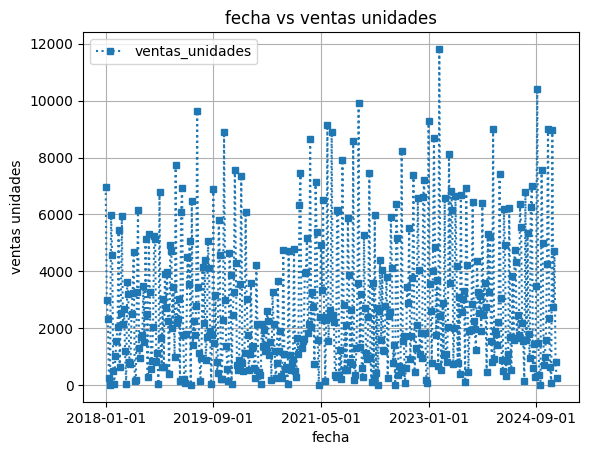

In [7]:
#Linea

data.plot(kind='line', x = 'fecha', y = 'ventas_unidades', linestyle="dotted", marker='s', markersize=5)

plt.title('fecha vs ventas unidades')
plt.xlabel('fecha')
plt.ylabel('ventas unidades')
plt.grid(True)
plt.show()

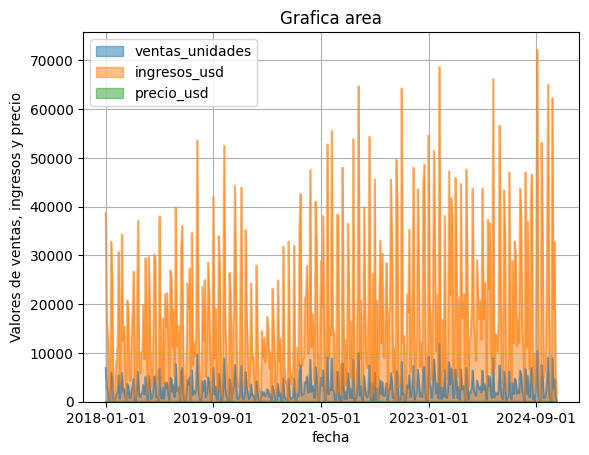

In [8]:
#Area aca no esta bien pero se entiende la idea
data.plot(kind = 'area', stacked=False, x='fecha', y = ['ventas_unidades', 'ingresos_usd', 'precio_usd'])
plt.title('Grafica area')
plt.xlabel('fecha')
plt.ylabel('Valores de ventas, ingresos y precio')
plt.grid(True)
plt.show()

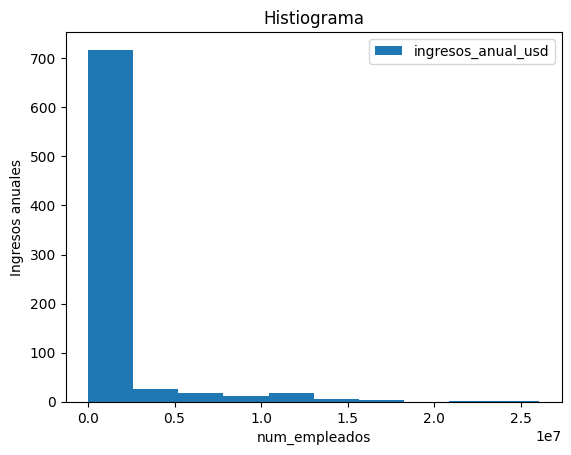

In [9]:
#Histiograma

df.plot(kind = 'hist', x='num_empleados', y='ingresos_anual_usd')
plt.title('Histiograma')
plt.xlabel('num_empleados')
plt.ylabel('Ingresos anuales')
plt.show()

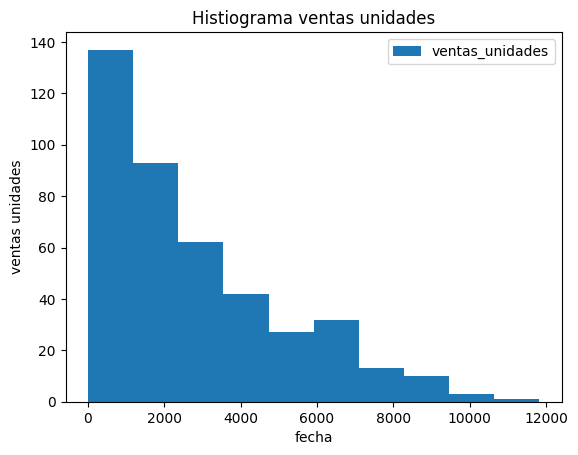

In [10]:
data.plot(kind = 'hist', x='fecha', y='ventas_unidades')
plt.title('Histiograma ventas unidades')
plt.xlabel('fecha')
plt.ylabel('ventas unidades')
plt.show()

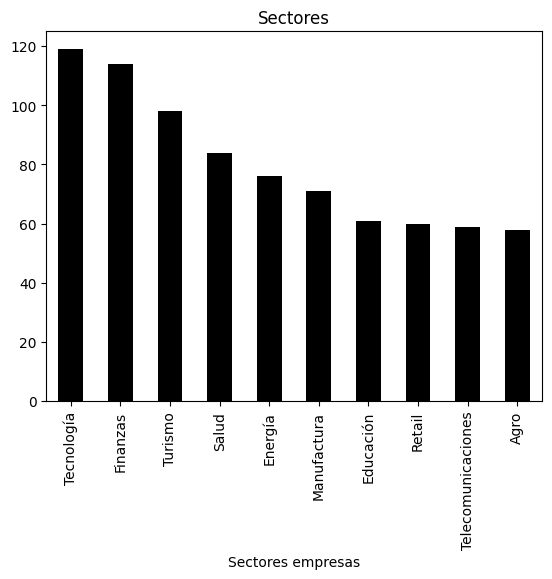

In [11]:
#Barras
df['sector'].value_counts().plot(kind='bar', color = 'black') #kind = 'barh' si lo quiero horizontal
plt.title('Sectores')
plt.xlabel('Sectores empresas')
plt.show()

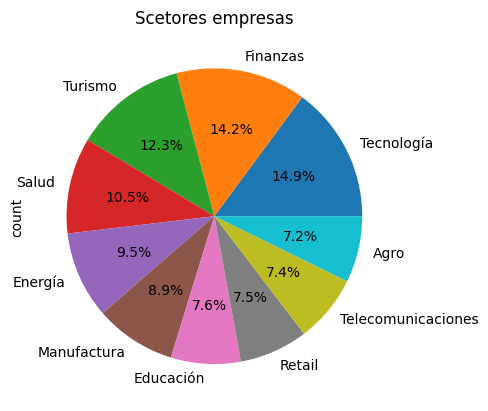

In [12]:
# pie

df['sector'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Scetores empresas')
plt.show()

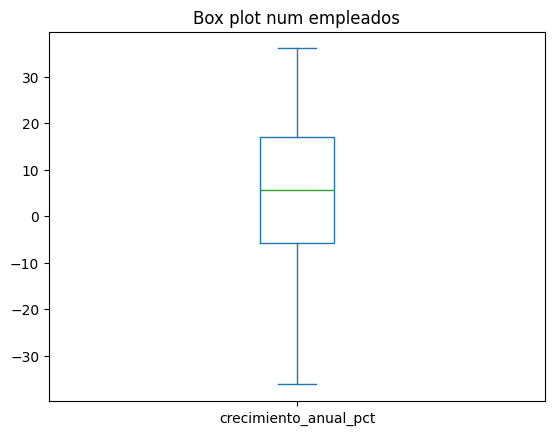

In [13]:
# Box plots

df['crecimiento_anual_pct'].plot(kind='box')
plt.title('Box plot num empleados')
plt.show()

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%203/images/boxplot_complete.png" width="440," align="center">

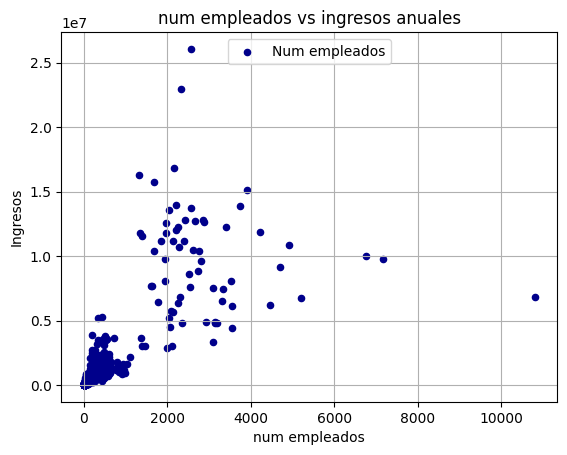

In [14]:
#Scatter plot

df.plot(kind='scatter', x='num_empleados', y='ingresos_anual_usd', color = 'darkblue', marker='o', s = 20)
plt.title('num empleados vs ingresos anuales')
plt.xlabel('num empleados')
plt.ylabel('Ingresos')
plt.grid(True)
plt.legend(["Num empleados"], loc='upper center')
plt.show()

## Waffle charts & Word Clouds

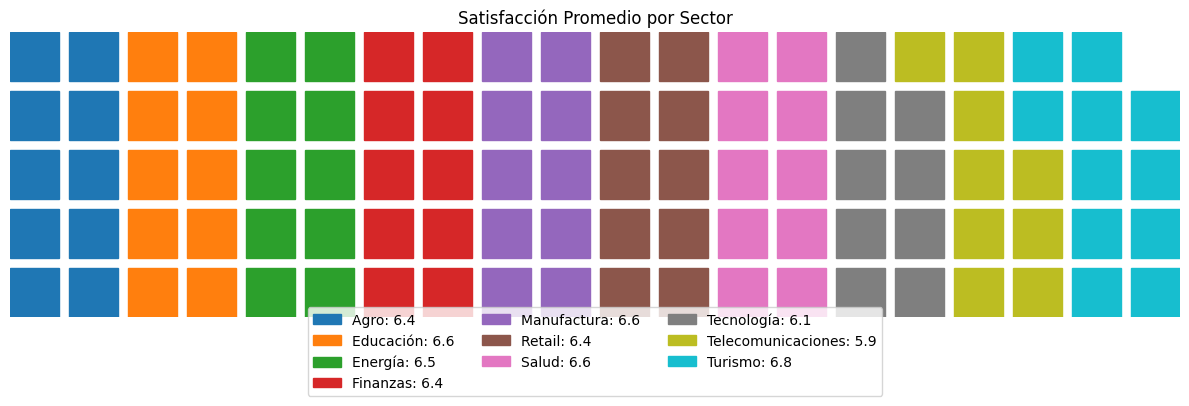

In [15]:
# waffle chart

conteo_sector = df.groupby('sector')['satisfaccion_empleados'].mean().round(1)

fig = plt.figure(FigureClass=Waffle,
                 rows=5, 
                 columns=20,
                 values=conteo_sector.values,
                 labels=[f"{s}: {v}" for s, v in zip(conteo_sector.index, conteo_sector.values)],
                 cmap_name='tab10',
                 legend={'loc': 'lower center', 'bbox_to_anchor': (0.5, -0.3), 'ncol': 3},
                 figsize=(12, 6)
                )
plt.title('Satisfacción Promedio por Sector')
plt.tight_layout()
plt.show()


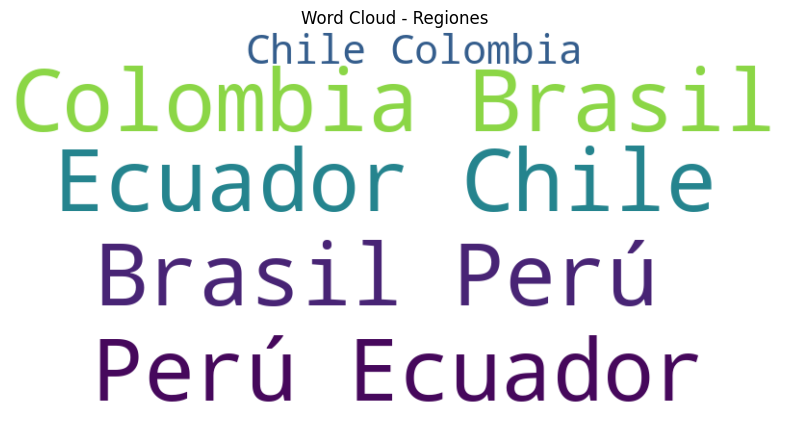

In [16]:


texto_regiones = ' '.join(data['region'].dropna().astype(str))


wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate(texto_regiones)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Regiones')
plt.show()

## Seaborn

<Axes: xlabel='sector', ylabel='count'>

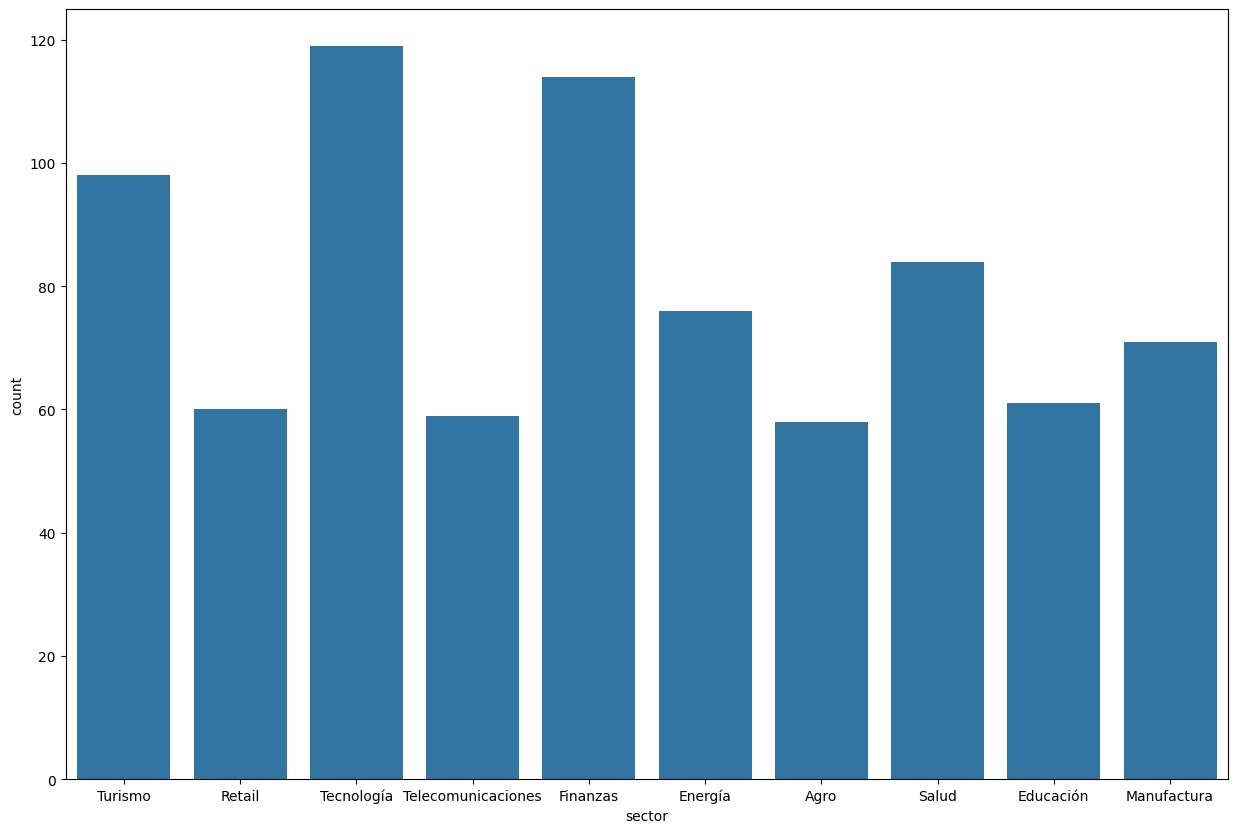

In [17]:
#Count plot
plt.figure(figsize=(15, 10))
sns.countplot(x='sector', data=df)

<Axes: xlabel='sector', ylabel='ingresos_anual_usd'>

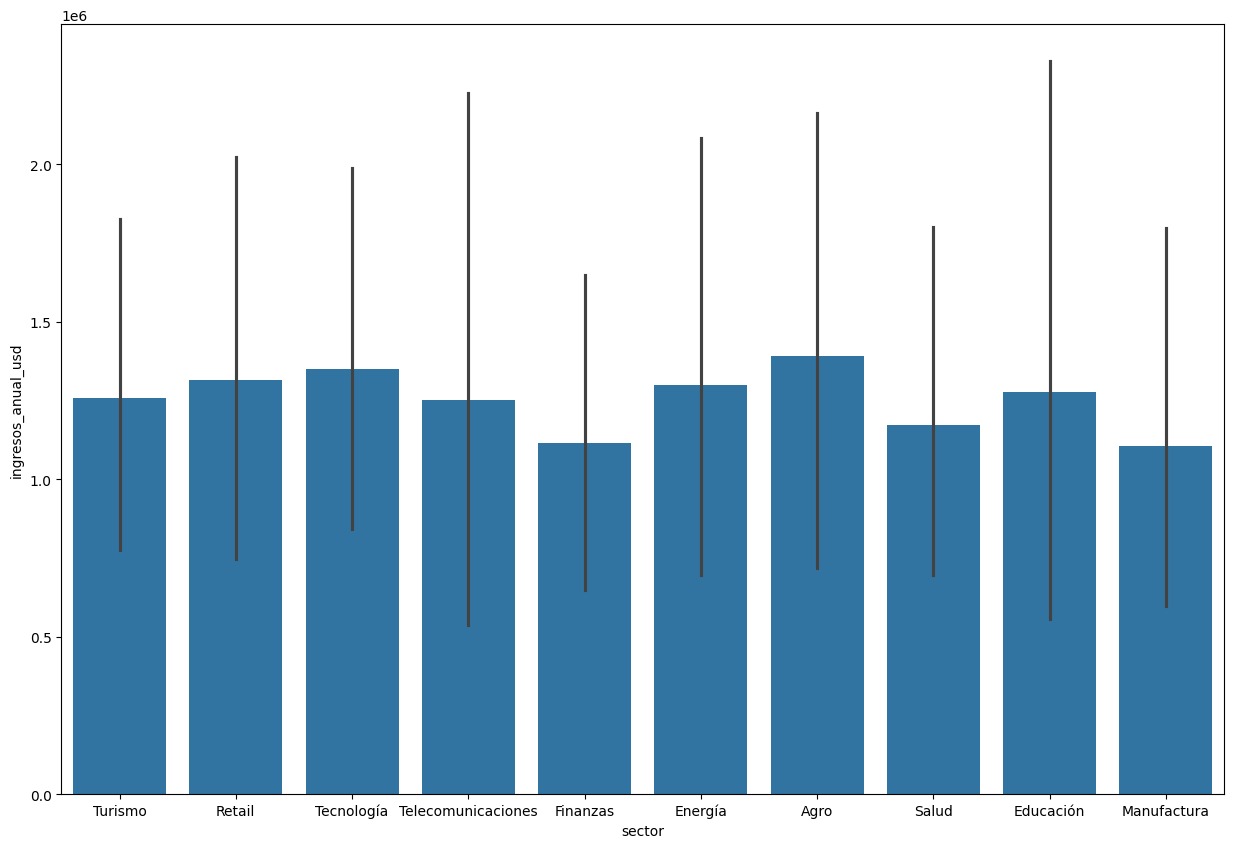

In [18]:
# bar plot
plt.figure(figsize=(15, 10))
sns.barplot(x='sector', y='ingresos_anual_usd', data=df)

<Axes: xlabel='ingresos_anual_usd', ylabel='num_empleados'>

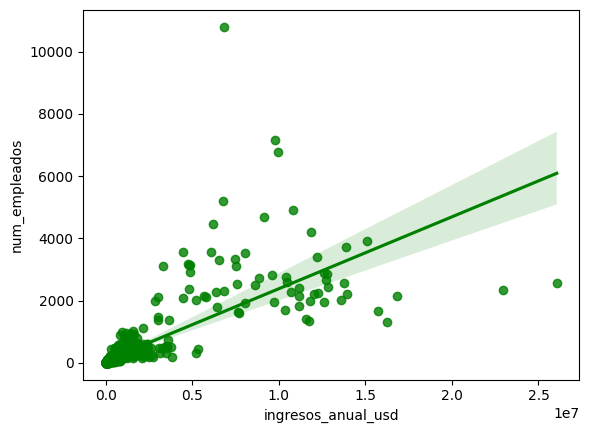

In [19]:
# regression plot

sns.regplot(x='ingresos_anual_usd', y='num_empleados', data=df, color='green')

<Axes: >

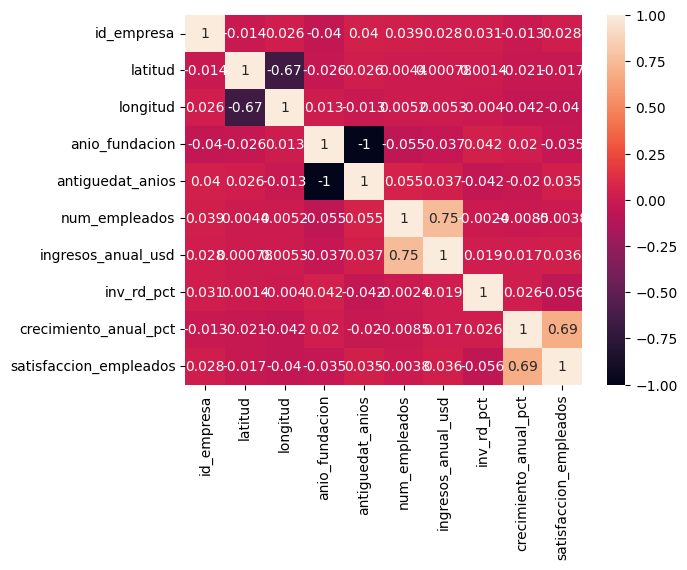

In [20]:
#Heatmap de correlacion

sns.heatmap(df.corr(numeric_only=True), annot = True)

## Plotly

### Graficas

In [21]:
# Scatter plot
fig = px.scatter(df, x='ingresos_anual_usd', y='num_empleados')
fig.show()


In [22]:
# Histiogram

fig = px.histogram(df, x='ingresos_anual_usd', y='num_empleados')
fig.show()

In [23]:
# line

fig = px.line(df, x='ingresos_anual_usd', y='num_empleados')
fig.show()

In [24]:
#Line 3d

fig = px.line_3d(df, x='ingresos_anual_usd', y='num_empleados', z='satisfaccion_empleados')
fig.show()

In [25]:
#Bar plot

fig = px.bar(df, x='sector', y='ingresos_anual_usd')
fig.show()

In [26]:
#Histiograma


fig = px.histogram(df, x='sector', y='ingresos_anual_usd')
fig.show()


In [27]:
#Pie

fig = px.pie(df, values = 'ingresos_anual_usd', names='sector')
fig.show()

In [28]:
# sunburst

data = dict(
    character=["Eve", "Cain", "Seth", "Enos", "Noam", "Abel", "Awan", "Enoch", "Azura"],
    parent=["", "Eve", "Eve", "Seth", "Seth", "Eve", "Eve", "Awan", "Eve" ],
    value=[10, 14, 12, 10, 2, 6, 6, 4, 4])

fig = px.sunburst(
    data,
    names='character',
    parents='parent',
    values='value',
    title="Family chart"
)
fig.show()

### treemaps

In [29]:
"""
fig = px.treemap(df,
                 path=['Category', 'Subcategory'],  # Define hierarchical structure
                 values='Value',  # Size of each rectangle
                 title='Treemap Example')  # Title of the treemap

"""


fig = px.treemap(df,
                 path=['sector', 'tamanio'],
                 values='ingresos_anual_usd',
                 title='Treemap')

fig.show()

### dashboards

## Dash